# Michael time-frequency lateralization

Python version of `time_freq_lateralization.m`. Select either an adaptive Hanning window (`cycles / frequency`) or one fixed window for every frequency. The analysis preserves single-trial contra-minus-ipsi log-power and caches each subject.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_DIR = Path('/home/dilay/project2/tw')
SCRIPT_DIR = PROJECT_DIR / 'travelling_waves/tw/fft/micheal'
sys.path.insert(0, str(SCRIPT_DIR))

from time_freq_lateralization import (
    AnalysisConfig,
    cluster_sign_flip_2d,
    default_output_dir,
    run_analysis,
)


## Parameters

- `adaptive`: FieldTrip-style frequency-dependent window. With 5 cycles, the window is 833 ms at 6 Hz, 500 ms at 10 Hz, and 312 ms at 16 Hz.
- `fixed`: every frequency uses `FIXED_WINDOW_MS`.
- `TOI_STEP_SAMPLES=5` at 500 Hz gives one output point every 10 ms.

In [3]:
WINDOW_MODE = 'fixed'       # 'adaptive' or 'fixed'
CYCLES = 5.0                  # used by adaptive mode
FIXED_WINDOW_MS = 500.0       # used by fixed mode
FREQUENCY_MIN = 6.0
FREQUENCY_MAX = 16.0
FREQUENCY_STEP = 0.5
TOI = (-0.1,6.0)
TOI_STEP_SAMPLES = 5
BATCH_TRIALS = 32
SUBJECTS = list(range(1, 20))

config = AnalysisConfig(
    frequency_min=FREQUENCY_MIN,
    frequency_max=FREQUENCY_MAX,
    frequency_step=FREQUENCY_STEP,
    toi_min=TOI[0],
    toi_max=TOI[1],
    toi_step_samples=TOI_STEP_SAMPLES,
    window_mode=WINDOW_MODE,
    cycles=CYCLES,
    fixed_window_ms=FIXED_WINDOW_MS,
    batch_trials=BATCH_TRIALS,
)
data_dir = PROJECT_DIR / 'Data/Micheal_Data_exp2'
output_dir = default_output_dir(config)
output_dir


PosixPath('/home/dilay/project2/tw/results/freq_python/fixed_500ms')

## Run or load analysis

The first run computes all requested subjects. Later runs reuse subject caches when the complete parameter configuration matches.

In [4]:
RUN_ANALYSIS = True
OVERWRITE = False

group_file = output_dir / 'group_freq_lateralization.npz'
if RUN_ANALYSIS:
    group_file = run_analysis(
        SUBJECTS,
        data_dir,
        output_dir,
        config,
        overwrite=OVERWRITE,
    )
elif not group_file.exists():
    raise FileNotFoundError(f'{group_file} does not exist; set RUN_ANALYSIS=True')

with np.load(group_file, allow_pickle=False) as result:
    freq_lat_sub = result['freq_lat_sub']
    frequencies = result['frequencies']
    plot_time = result['plot_time']
    subjects = result['subjects']

print('subjects:', len(subjects))
print('data shape:', freq_lat_sub.shape, '(subject, frequency, time)')


Subject 01
  trimmed incomplete edge toi values: requested -98..5992 ms, using -98..5752 ms
  session 1: 769 trials, cue=1
    6 Hz: 250 samples (500.0 ms)
    6.5 Hz: 250 samples (500.0 ms)
    7 Hz: 250 samples (500.0 ms)
    7.5 Hz: 250 samples (500.0 ms)
    8 Hz: 250 samples (500.0 ms)
    8.5 Hz: 250 samples (500.0 ms)
    9 Hz: 250 samples (500.0 ms)
    9.5 Hz: 250 samples (500.0 ms)
    10 Hz: 250 samples (500.0 ms)
    10.5 Hz: 250 samples (500.0 ms)
    11 Hz: 250 samples (500.0 ms)
    11.5 Hz: 250 samples (500.0 ms)
    12 Hz: 250 samples (500.0 ms)
    12.5 Hz: 250 samples (500.0 ms)
    13 Hz: 250 samples (500.0 ms)
    13.5 Hz: 250 samples (500.0 ms)
    14 Hz: 250 samples (500.0 ms)
    14.5 Hz: 250 samples (500.0 ms)
    15 Hz: 250 samples (500.0 ms)
    15.5 Hz: 250 samples (500.0 ms)
    16 Hz: 250 samples (500.0 ms)
  trimmed incomplete edge toi values: requested -98..5992 ms, using -98..5752 ms
  session 2: 770 trials, cue=2
    6 Hz: 250 samples (500.0 ms)
    6.

## Group cluster-permutation test and figure

This is a two-sided sign-flip cluster-mass test across subjects with four-neighbour connectivity in frequency × time.

In [5]:
N_PERMUTATIONS = 50_000
CLUSTER_ALPHA = 0.05
CLUSTER_P = 0.05

group_mean, clusters = cluster_sign_flip_2d(
    freq_lat_sub,
    permutations=N_PERMUTATIONS,
    cluster_alpha=CLUSTER_ALPHA,
    cluster_p=CLUSTER_P,
    seed=2026,
)
print(f'significant clusters: {len(clusters)}')
for index, cluster in enumerate(clusters, start=1):
    rows, columns = np.where(cluster['mask'])
    print(
        f"cluster {index}: p={cluster['p']:.6f}, "
        f"{plot_time[columns.min()]:.0f}–{plot_time[columns.max()]:.0f} ms, "
        f"{frequencies[rows.min()]:g}–{frequencies[rows.max()]:g} Hz"
    )


significant clusters: 2
cluster 1: p=0.031879, 52–872 ms, 6–14.5 Hz
cluster 2: p=0.015680, 2332–3392 ms, 6–16 Hz


saved: /home/dilay/project2/tw/results/freq_python/fixed_500ms/freq_lateralization_contra_ipsi.png


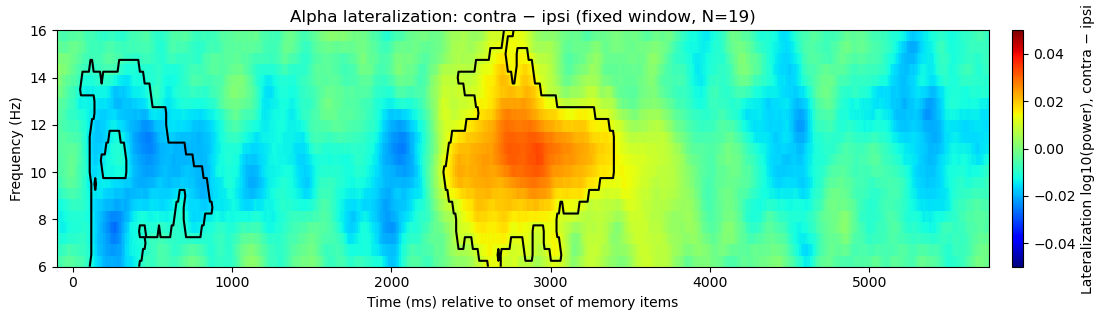

In [6]:
fig, ax = plt.subplots(figsize=(12, 3.3))
image = ax.imshow(
    group_mean,
    origin='lower',
    aspect='auto',
    extent=[plot_time[0], plot_time[-1], frequencies[0], frequencies[-1]],
    cmap='jet',
    vmin=-0.05,
    vmax=0.05,
    interpolation='nearest',
)
for cluster in clusters:
    ax.contour(
        plot_time,
        frequencies,
        cluster['mask'].astype(float),
        levels=[0.5],
        colors='black',
        linewidths=1.5,
    )
ax.set_xlim(plot_time[0], plot_time[-1])
ax.set_ylim(FREQUENCY_MIN, FREQUENCY_MAX)
ax.set_xlabel('Time (ms) relative to onset of memory items')
ax.set_ylabel('Frequency (Hz)')
ax.set_title(
    f'Alpha lateralization: contra − ipsi '
    f'({WINDOW_MODE} window, N={len(subjects)})'
)
ax.tick_params(direction='out')
colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label('Lateralization log10(power), contra − ipsi')
fig.tight_layout()

figure_file = output_dir / 'freq_lateralization_contra_ipsi.png'
fig.savefig(figure_file, dpi=300, bbox_inches='tight')
fig.savefig(figure_file.with_suffix('.pdf'), bbox_inches='tight')
print('saved:', figure_file)
plt.show()


## Optional: compare adaptive and fixed results

Run both configurations first, then execute this cell.

In [ ]:
adaptive_file = PROJECT_DIR / 'results/freq_python/adaptive_5cycles/group_freq_lateralization.npz'
fixed_file = PROJECT_DIR / 'results/freq_python/fixed_500ms/group_freq_lateralization.npz'

if adaptive_file.exists() and fixed_file.exists():
    with np.load(adaptive_file) as adaptive, np.load(fixed_file) as fixed:
        adaptive_mean = adaptive['freq_lat_sub'].mean(axis=0)
        fixed_mean = fixed['freq_lat_sub'].mean(axis=0)
        comparison_time = adaptive['plot_time']
        comparison_frequency = adaptive['frequencies']

    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharex=True, sharey=True)
    limit = max(np.abs(adaptive_mean).max(), np.abs(fixed_mean).max())
    for ax, values, title in zip(
        axes,
        (adaptive_mean, fixed_mean),
        ('Adaptive: 5 cycles/frequency', 'Fixed: 500 ms'),
    ):
        image = ax.imshow(
            values,
            origin='lower',
            aspect='auto',
            extent=[comparison_time[0], comparison_time[-1],
                    comparison_frequency[0], comparison_frequency[-1]],
            cmap='RdBu_r', vmin=-limit, vmax=limit,
        )
        ax.set_title(title)
        ax.set_xlabel('Time (ms)')
    axes[0].set_ylabel('Frequency (Hz)')
    fig.colorbar(image, ax=axes, label='Contra − ipsi log10(power)')
    plt.show()
else:
    print('Run both adaptive and fixed analyses before comparison.')
